In [436]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [437]:
df = pd.read_csv("Mall_Customers.csv")

In [438]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [439]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (200, 5)


In [440]:
print("Columns in Dataset:")
print(df.columns)

Columns in Dataset:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')


In [441]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [442]:
print(df.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [443]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [444]:
df.sample(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
37,38,Female,30,34,73
49,50,Female,31,40,42
13,14,Female,24,20,77
91,92,Male,18,59,41
39,40,Female,20,37,75


In [445]:
import matplotlib.pyplot as plt

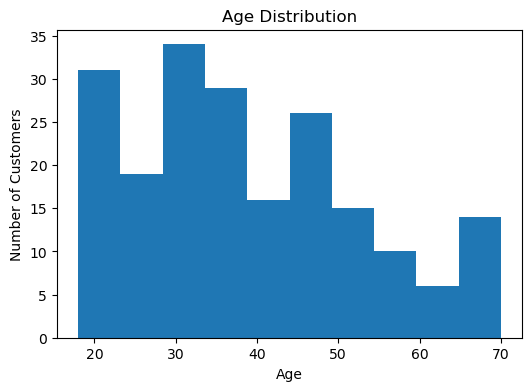

In [446]:
plt.figure(figsize=(6,4))
plt.hist(df['Age'], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

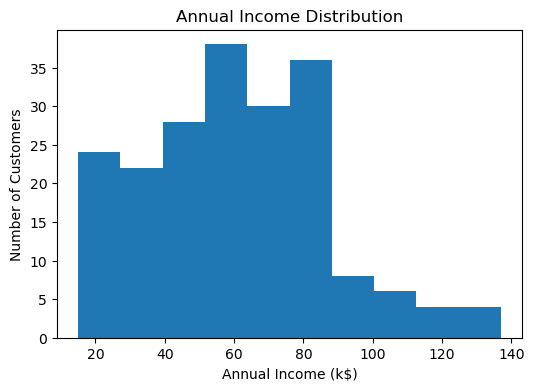

In [447]:
plt.figure(figsize=(6,4))
plt.hist(df['Annual Income (k$)'], bins=10)
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")
plt.show()

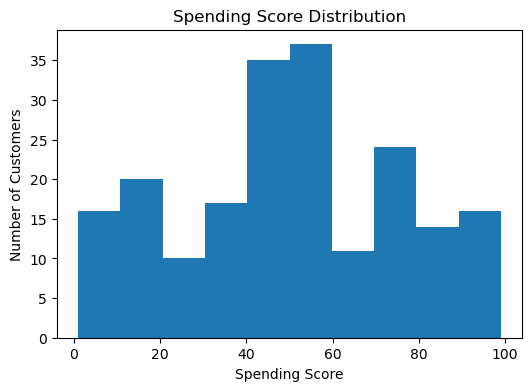

In [448]:
plt.figure(figsize=(6,4))
plt.hist(df['Spending Score (1-100)'], bins=10)
plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")
plt.show()

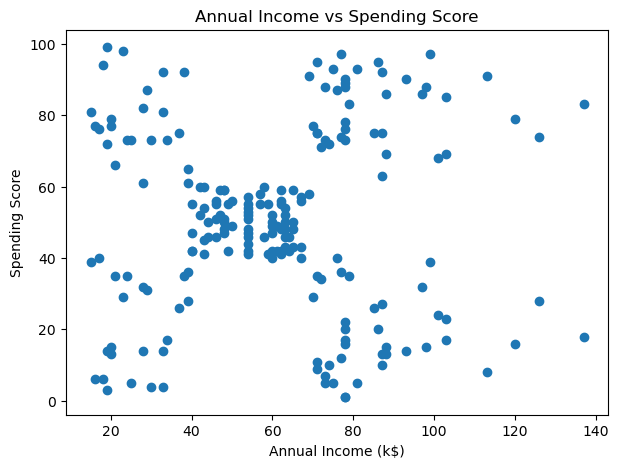

In [449]:
plt.figure(figsize=(7,5))

plt.scatter(df['Annual Income (k$)'],
            df['Spending Score (1-100)'])

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.show()

In [450]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
print(X.head())

   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


In [451]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled)

print("Shape of Scaled Data:", X_scaled.shape)

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]
 [-1.66266033  1.00159627]
 [-1.62449091 -1.71591298]
 [-1.62449091  1.70038436]
 [-1.58632148 -1.83237767]
 [-1.58632148  0.84631002]
 [-1.58632148 -1.4053405 ]
 [-1.58632148  1.89449216]
 [-1.54815205 -1.36651894]
 [-1.54815205  1.04041783]
 [-1.54815205 -1.44416206]
 [-1.54815205  1.11806095]
 [-1.50998262 -0.59008772]
 [-1.50998262  0.61338066]
 [-1.43364376 -0.82301709]
 [-1.43364376  1.8556706 ]
 [-1.39547433 -0.59008772]
 [-1.39547433  0.88513158]
 [-1.3573049  -1.75473454]
 [-1.3573049   0.88513158]
 [-1.24279661 -1.4053405 ]
 [-1.24279661  1.23452563]
 [-1.24279661 -0.7065524 ]
 [-1.24279661  0.41927286]
 [-1.20462718 -0.74537397]
 [-1.20462718  1.42863343]
 [-1.16645776 -1.7935561 ]
 [-1.16645776  0.88513158]
 [-1.05194947 -1.7935561 ]
 [-1.05194947  1.62274124]
 [-1.05194947 -1.4053405 ]
 [-1.05194947  1.19570407]
 [-1.01378004 -1.28887582]
 

In [452]:
wcss = []

In [453]:
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    print(wcss)

[400.0]
[400.0, 273.6688866264201]
[400.0, 273.6688866264201, 157.70400815035947]
[400.0, 273.6688866264201, 157.70400815035947, 109.22822707921345]
[400.0, 273.6688866264201, 157.70400815035947, 109.22822707921345, 65.56840815571681]
[400.0, 273.6688866264201, 157.70400815035947, 109.22822707921345, 65.56840815571681, 60.13287487193421]
[400.0, 273.6688866264201, 157.70400815035947, 109.22822707921345, 65.56840815571681, 60.13287487193421, 49.66824483736797]
[400.0, 273.6688866264201, 157.70400815035947, 109.22822707921345, 65.56840815571681, 60.13287487193421, 49.66824483736797, 37.319122878338824]
[400.0, 273.6688866264201, 157.70400815035947, 109.22822707921345, 65.56840815571681, 60.13287487193421, 49.66824483736797, 37.319122878338824, 32.49508119910091]
[400.0, 273.6688866264201, 157.70400815035947, 109.22822707921345, 65.56840815571681, 60.13287487193421, 49.66824483736797, 37.319122878338824, 32.49508119910091, 30.05932269404221]


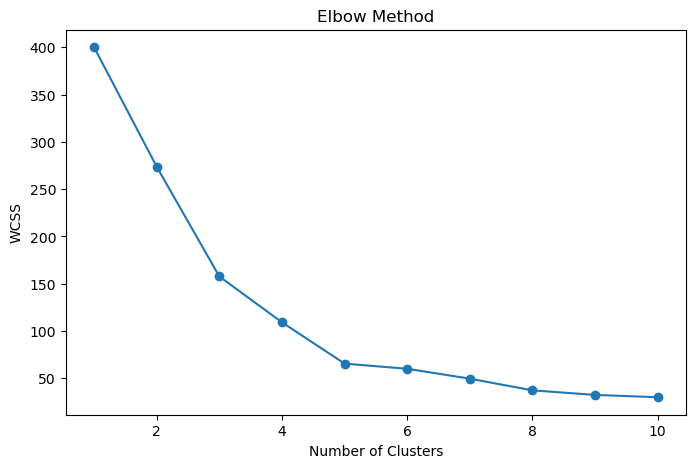

In [454]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [455]:
kmeans = KMeans(n_clusters=5, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

print(df.head())

print(df['Cluster'].value_counts())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  
Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


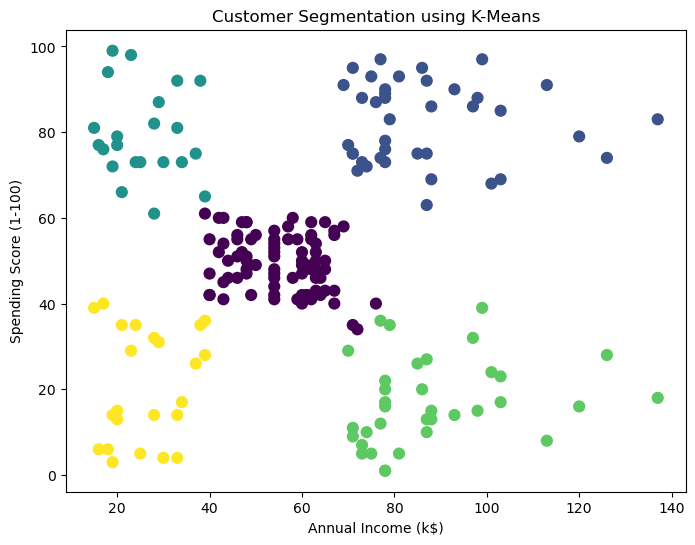

In [456]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis',
    s=60
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.show()

In [457]:
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

print(centroids)

[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


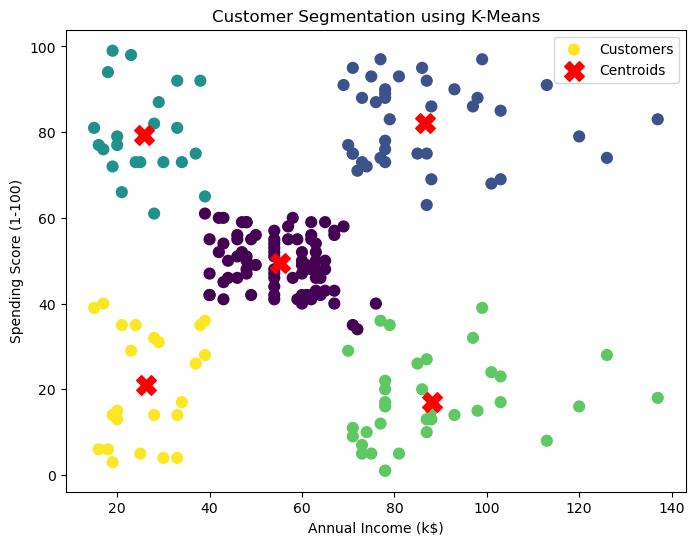

In [458]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis',
    s=60,
    label='Customers'
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    marker='X',
    s=200,
    color='red',
    label='Centroids'
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()

plt.show()

In [459]:
print(df['Cluster'].value_counts())

cluster_summary = df.groupby('Cluster')[[
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]].mean()

print(cluster_summary)


Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        25.272727           25.727273               79.363636
3        41.114286           88.200000               17.114286
4        45.217391           26.304348               20.913043


In [460]:
df.to_csv("clustered_customers.csv", index=False)

print("File saved successfully!")

File saved successfully!
